# CSI 300 Hidden-State Risk Allocation - Cumulative Project Pipeline

**Stakeholder decision:** maintain full CSI 300 exposure or move to cash for the next 20 trading days. The output is advisory research and never an automatic order.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)


working from: hmm_course_project


## Stages 01-03 - Framing, tooling, and reusable Python

The primary stakeholder is a tactical asset-allocation committee chair. Success means improved out-of-sample risk-adjusted performance or drawdown behavior versus buy-and-hold, with assumptions and uncertainty visible. The repository uses environment-driven paths, pinned dependencies, and reusable modules in `src/`.

In [2]:
import json
import subprocess
import threading
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from src.cleaning import clean_market_data, cleaning_audit
from src.eda import eda_summary
from src.features import FEATURE_COLUMNS, build_period_observations
from src.ingest import acquire_hs300
from src.outliers import iqr_outlier_flags
from src.pipeline import run_full_pipeline

pd.set_option('display.max_columns', 30)


## Stages 04-05 - Data acquisition and storage

In [3]:
raw, source_metadata = acquire_hs300(
    'data/raw/hs300_daily.csv',
    start='2005-01-01',
    end='2026-09-01',
    refresh=False,
)
print('raw rows:', len(raw))
print('date range:', raw['date'].min().date(), 'to', raw['date'].max().date())
display(pd.Series(source_metadata, name='value').to_frame())


raw rows: 5261
date range: 2005-01-04 to 2026-08-31


,value
symbol,000300
requested_start,2005-01-01
requested_end,2026-09-01
actual_start,2005-01-04
actual_end,2026-08-31
rows,5261
source_used,committed cache
retrieved_at_utc,2026-09-01T02:51:45.195024+00:00
fallback_errors,{'yfinance': 'RuntimeError: yfinance returned ...
sha256,c75deb91a6fc4749780228610036e6a6b472ffe3312b2b...


The default run uses the committed raw snapshot for offline reproducibility. A live refresh is explicit and records provider fallback errors, row count, dates, retrieval time, and checksum.

## Stages 06-07 - Cleaning and outlier assumptions

In [4]:
clean = clean_market_data(raw)
clean['return_outlier'] = iqr_outlier_flags(clean['daily_return'], multiplier=3.0)
display(cleaning_audit(raw, clean))
print('valid extreme returns retained and flagged:', int(clean['return_outlier'].sum()))


,check,raw,cleaned
0,rows,5261,5261
1,duplicate_dates,0,0
2,missing_prices,0,0
3,nonpositive_volume,0,0


valid extreme returns retained and flagged: 71


Valid extreme returns are retained because crisis observations are part of the allocation problem. The baseline later clips features using bounds learned only from each training window, and a no-clipping scenario measures sensitivity.

## Stage 08 - Exploratory analysis

,column,dtype,count,missing,unique,mean,std,min,max,skew
0,date,datetime64[us],5261,0,5261,NaN,NaN,NaN,NaN,NaN
1,open,float64,5261,0,5254,3.329427e+03,1.085005e+03,8.165460e+02,5.922071e+03,-0.3704
2,high,float64,5261,0,5257,3.359195e+03,1.092706e+03,8.238600e+02,5.930912e+03,-0.3732
3,low,float64,5261,0,5259,3.299784e+03,1.075024e+03,8.077840e+02,5.815609e+03,-0.3771
4,close,float64,5261,0,5257,3.332107e+03,1.084630e+03,8.180330e+02,5.877202e+03,-0.3735
5,volume,float64,5261,0,5261,1.117292e+10,8.368353e+09,5.014525e+08,6.864391e+10,1.9467
6,daily_return,float64,5260,1,5260,4.000000e-04,1.580000e-02,-9.240000e-02,9.340000e-02,-0.3316
7,log_return,float64,5260,1,5260,3.000000e-04,1.580000e-02,-9.690000e-02,8.930000e-02,-0.4819
8,return_outlier,bool,5261,0,2,1.350000e-02,1.154000e-01,0.000000e+00,1.000000e+00,8.4352


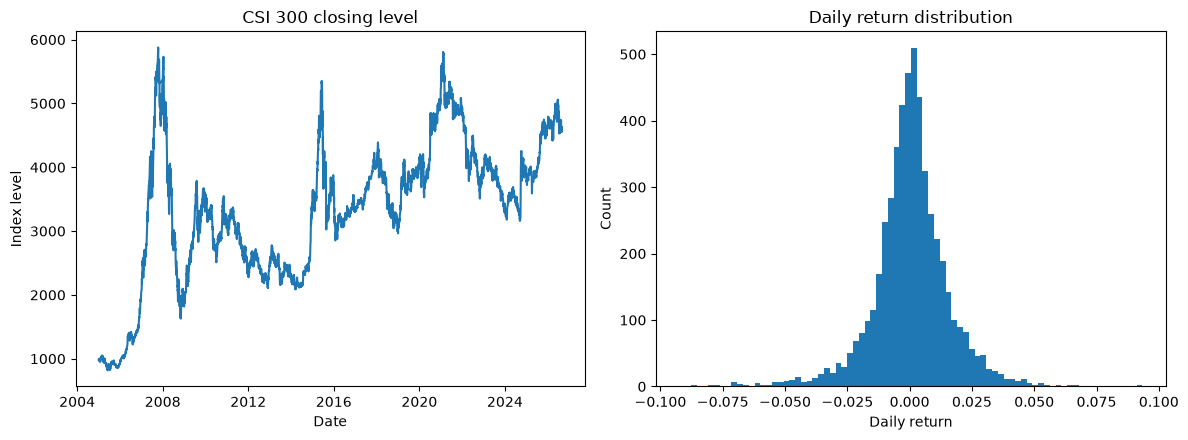

In [5]:
display(eda_summary(clean).round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(clean['date'], clean['close'])
axes[0].set(title='CSI 300 closing level', xlabel='Date', ylabel='Index level')
axes[1].hist(clean['daily_return'].dropna(), bins=80)
axes[1].set(title='Daily return distribution', xlabel='Daily return', ylabel='Count')
plt.tight_layout()
plt.show()


## Stage 09 - Leakage-safe feature engineering

In [6]:
observations = build_period_observations(clean, holding_period=20)
print('period observations:', observations.shape)
display(observations.head())
display(observations[FEATURE_COLUMNS + ['future_return']].describe().T.round(4))


period observations: (262, 8)


,date,next_date,close,period_return,return_sharpe,volume_ratio,half_return,future_return
0,2005-02-01,2005-03-10,955.951,-0.027313,-0.505232,0.144237,-0.019225,0.069524
1,2005-03-10,2005-04-07,1022.413,0.069524,0.909413,-0.063135,-0.022045,-0.036854
2,2005-04-07,2005-05-12,984.733,-0.036854,-0.565831,0.016110,0.020659,-0.100447
3,2005-05-12,2005-06-09,885.820,-0.100447,-1.777886,-0.037489,-0.061612,0.030236
4,2005-06-09,2005-07-07,912.604,0.030236,0.345256,0.245975,0.064471,-0.074375


,count,mean,std,min,25%,50%,75%,max
period_return,262.0,0.0085,0.0732,-0.1987,-0.0323,0.0051,0.0444,0.2996
return_sharpe,262.0,0.2036,1.0873,-2.3185,-0.5540,0.1219,0.8397,3.0108
volume_ratio,262.0,0.0062,0.1159,-0.2251,-0.0762,-0.0056,0.0772,0.5338
half_return,262.0,0.0049,0.0505,-0.1641,-0.0235,0.0048,0.0290,0.2143
future_return,262.0,0.0086,0.0731,-0.1987,-0.0323,0.0056,0.0444,0.2996


`period_return` captures medium-horizon direction; `return_sharpe` distinguishes stable from noisy moves; `volume_ratio` tracks participation; and `half_return` captures acceleration or reversal. The same row's `future_return` is evaluation-only.

In [7]:
# Refactor check: manually calculate the first period return and compare it with src.features.
first_index = 20
manual_period_return = clean.loc[first_index, 'close'] / clean.loc[first_index - 20, 'close'] - 1
assert np.isclose(manual_period_return, observations.loc[0, 'period_return'])
print('manual and imported feature results match:', manual_period_return)


manual and imported feature results match: -0.027312946558485263


## Stages 10-12 - Walk-forward modeling, evaluation, and delivery

In [8]:
results = run_full_pipeline(refresh_data=False)
scenario_metrics = results['scenarios'].copy()
display(scenario_metrics.round(4))
print('bootstrap mean active-return interval:', results['uncertainty'])


,n_periods,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,prediction_mae,prediction_rmse,direction_accuracy,exposure_rate,turnover_events,scenario
0,182,0.0668,0.1627,0.4764,-0.3998,0.0345,0.2115,0.2638,-0.4264,0.0447,0.0610,0.5495,0.6209,71,baseline_5_state
1,182,0.0355,0.1708,0.2875,-0.3513,0.0345,0.2115,0.2638,-0.4264,0.0440,0.0601,0.5220,0.6264,67,3_state
2,182,0.0204,0.1722,0.2009,-0.4355,0.0345,0.2115,0.2638,-0.4264,0.0437,0.0591,0.5220,0.5824,83,4_state
3,182,0.0228,0.1404,0.2279,-0.3621,0.0345,0.2115,0.2638,-0.4264,0.0455,0.0601,0.4780,0.5055,69,no_feature_clipping


bootstrap mean active-return interval: {'mean': 0.0017246396099441787, 'ci_low': -0.0040861336093714175, 'ci_high': 0.007387416675766581}


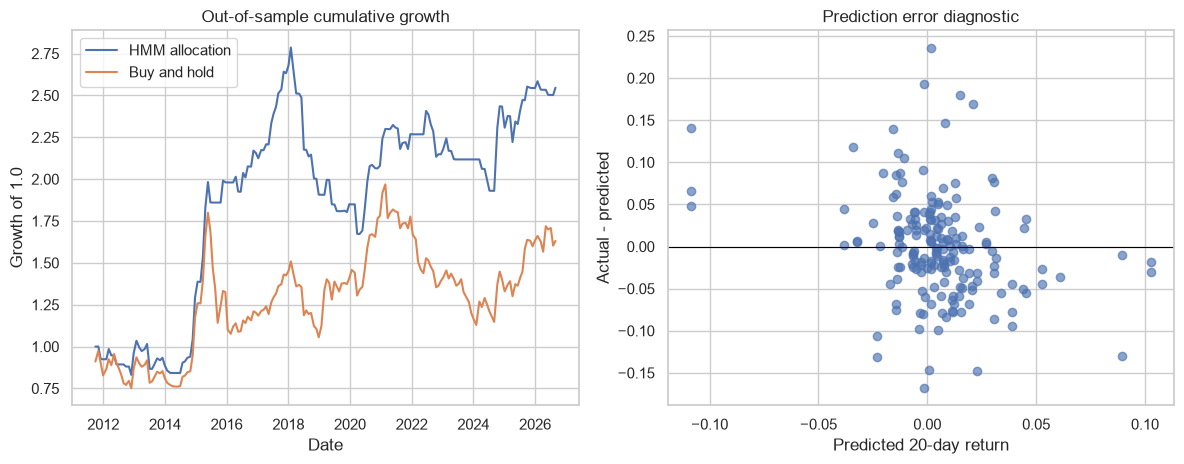

In [9]:
backtest = results['backtest']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(backtest['next_date'], backtest['strategy_nav'], label='HMM allocation')
axes[0].plot(backtest['next_date'], backtest['benchmark_nav'], label='Buy and hold')
axes[0].set(title='Out-of-sample cumulative growth', xlabel='Date', ylabel='Growth of 1.0')
axes[0].legend()
errors = backtest['future_return'] - backtest['predicted_return']
axes[1].scatter(backtest['predicted_return'], errors, alpha=0.65)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(title='Prediction error diagnostic', xlabel='Predicted 20-day return', ylabel='Actual - predicted')
plt.tight_layout()
plt.show()


### Risk-aware interpretation

The five-state candidate has a 6.68% annualized return, 0.48 Sharpe ratio, and -39.98% maximum drawdown, versus 3.45%, 0.26, and -42.64% for buy-and-hold. Direction accuracy is 54.95%. Three-/four-state and no-clipping alternatives are weaker, showing assumption sensitivity. The bootstrap 95% interval for mean active 20-day return is -0.41% to 0.74%, so the evidence is not decisive. The stakeholder recommendation is shadow monitoring rather than live deployment.

In [10]:
required_report_assets = [
    'reports/final_report.md',
    'reports/images/cumulative_performance.png',
    'reports/images/drawdown_comparison.png',
    'reports/images/scenario_comparison.png',
    'reports/images/hidden_states.png',
]
for path in required_report_assets:
    print(path, 'OK' if Path(path).exists() else 'MISSING')


reports/final_report.md OK
reports/images/cumulative_performance.png OK
reports/images/drawdown_comparison.png OK
reports/images/scenario_comparison.png OK
reports/images/hidden_states.png OK


## Stage 13 - Saved model and API evidence

In [11]:
from werkzeug.serving import make_server
from app import create_app

server = make_server('127.0.0.1', 0, create_app())
port = server.server_port
thread = threading.Thread(target=server.serve_forever, daemon=True)
thread.start()
time.sleep(0.3)

try:
    health = requests.get(f'http://127.0.0.1:{port}/health', timeout=5)
    latest = requests.get(f'http://127.0.0.1:{port}/latest', timeout=5)
    bad = requests.post(f'http://127.0.0.1:{port}/predict', json={'features': {'wrong': 1}}, timeout=5)
    print('GET /health:', health.status_code, health.json())
    print('GET /latest:', latest.status_code, latest.json())
    print('POST bad /predict:', bad.status_code, bad.json())
    assert health.status_code == 200 and latest.status_code == 200 and bad.status_code == 400
finally:
    server.shutdown()
    thread.join(timeout=5)


127.0.0.1 - - [01/Sep/2026 11:06:44] "GET /health HTTP/1.1" 200 -


127.0.0.1 - - [01/Sep/2026 11:06:44] "GET /latest HTTP/1.1" 200 -


127.0.0.1 - - [01/Sep/2026 11:06:44] "POST /predict HTTP/1.1" 400 -


GET /health: 200 {'model_version': '1.0.0', 'status': 'ok', 'trained_through': '2026-08-31'}
GET /latest: 200 {'expected_period_return': -0.004983930288874672, 'model_version': '1.0.0', 'recommended_exposure': 0, 'regime': 'risk_off', 'state': 4, 'trained_through': '2026-08-31'}
POST bad /predict: 400 {'error': "feature keys mismatch; missing=['half_return', 'period_return', 'return_sharpe', 'volume_ratio'], extra=['wrong']"}


## Stages 14-15 - Monitoring and orchestration

In [12]:
required_operating_docs = [
    'docs/monitoring_plan.md',
    'docs/handoff_plan.md',
    'docs/orchestration_plan.md',
]
for path in required_operating_docs:
    print(path, 'OK' if Path(path).exists() else 'MISSING')

cli = subprocess.run(
    [sys.executable, '-m', 'src.run_step',
     '--input', 'data/raw/hs300_daily.csv',
     '--output', 'data/processed/hs300_clean_cli.csv',
     '--log', 'logs/pipeline.log'],
    check=True, capture_output=True, text=True,
)
print(cli.stderr.strip())
assert Path('data/processed/hs300_clean_cli.csv').exists()


docs/monitoring_plan.md OK
docs/handoff_plan.md OK
docs/orchestration_plan.md OK


2026-09-01 11:06:45,769 INFO clean step start input=data/raw/hs300_daily.csv output=data/processed/hs300_clean_cli.csv
2026-09-01 11:06:45,803 INFO clean step complete rows=5261


## Stage 16 - Final lifecycle review

In [13]:
required = [
    'README.md', 'requirements.txt', '.env.example',
    'data/raw/hs300_daily.csv', 'data/processed/hs300_clean.parquet',
    'src/ingest.py', 'src/cleaning.py', 'src/outliers.py', 'src/eda.py',
    'src/features.py', 'src/modeling.py', 'src/evaluation.py', 'src/run_step.py',
    'reports/final_report.md', 'model/regime_model.joblib', 'app.py',
    'docs/lifecycle_framework_guide.md', 'docs/project_summary.md',
]
checks = pd.Series({path: Path(path).exists() for path in required}, name='present')
display(checks.to_frame())
assert checks.all()
print('All 16 lifecycle stages map to present, runnable deliverables.')


,present
README.md,True
requirements.txt,True
.env.example,True
data/raw/hs300_daily.csv,True
data/processed/hs300_clean.parquet,True
src/ingest.py,True
src/cleaning.py,True
src/outliers.py,True
src/eda.py,True
src/features.py,True


All 16 lifecycle stages map to present, runnable deliverables.


## Final Recommendation

Keep the model in shadow mode, record forward signals before outcomes, validate data and costs independently, and require risk-chair approval before any allocation use. The repo is a complete reproducible research and handoff package; it is not evidence of guaranteed performance.